# Connect to google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


# Set dataset paths

Unzip and load RAF-DB datasets in cwd

In [2]:
!unzip -qqq /content/drive/MyDrive/drive_bys/Image/aligned.zip
!cp /content/drive/MyDrive/drive_bys/EmoLabel/list_patition_label.txt .

In [3]:
#path to the images and labelfile
rafdb_image_folder = 'aligned'
rafdb_label_file = 'list_patition_label.txt'

Unzip and load FER datasets in cwd

In [4]:
!tar xvzf '/content/drive/MyDrive/drive_bys/FER/fer2013.tar.gz'
fer_csv_file = '/content/fer2013/fer2013.csv'

fer2013/fer2013.csv
fer2013/README
fer2013/fer2013.bib
fer2013/


Unzip and load Affectnet in cwd

In [5]:
!unzip -qq /content/drive/MyDrive/drive_bys/affectnet/affectnet.zip
affectnet_image_folder = '/content/archive (3)/Test'

Unzip and load AER

In [3]:
!unzip -qqq /content/drive/MyDrive/drive_bys/'Autism emotion recogition dataset.zip'
aer_image_folder = '/content/Autism emotion recogition dataset/test/'

# Install Emotiefflib and Imports

In [7]:
!pip install emotiefflib[torch] -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 82.3 MB/s eta 0:00:00


In [4]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import json
import cv2
from emotiefflib.facial_analysis import EmotiEffLibRecognizer
from google.colab.patches import cv2_imshow
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import top_k_accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Preprocessing functions

Preprocessing and preparing RAF-DB for Deepface ingestion

In [9]:
def load_rafdb(image_folder, label_file,  split='train'):

    # 1. Paths Setup
    img_folder = image_folder
    label_file = label_file

    # 2. Parse the Label File
    df = pd.read_csv(label_file, sep=' ', header=None, names=['filename', 'label'])

    # 3. Filter by Split (Train vs Test)
    if split == 'train':
        df = df[df['filename'].str.startswith('train')]
    else:
        df = df[df['filename'].str.startswith('test')]

    df.reset_index(drop=True, inplace=True)

    # 4. Create a Full Path Column
    df['aligned_filename'] = df['filename'].str.replace('.jpg', '_aligned.jpg', regex=False)

    # construct the full paths by joining image_folder with the aligned filenames
    df['file_path'] = df['aligned_filename'].apply(lambda x: os.path.join(img_folder, x))
    df.drop(columns=['aligned_filename'], inplace=True)

    #mapping raf-db to the Deepface compatible naming scheme
    label_mapping = {
        1: 'surprise',
        2: 'fear',
        3: 'disgust',
        4: 'happy',
        5: 'sad',
        6: 'angry',
        7: 'neutral'
    }

    df['emotion_label'] = df['label'].map(label_mapping)

    return df

Preprocessing and preparing FER for Deepface ingestion

In [10]:
def load_fer(csv_file, split='train'):

  # 1. Read the CSV File
  df = pd.read_csv(csv_file)

  emotion_labels = {
  0: 'angry',
  1: 'disgust',
  2: 'fear',
  3: 'happy',
  4: 'sad',
  5: 'surprise',
  6: 'neutral'
  }

  df['emotion_label'] = df['emotion'].map(emotion_labels)

  if split == 'train':
    df = df[df['Usage'] == 'PublicTest']
  else:
    df = df[df['Usage'] == 'PublicTest']

  df.reset_index(drop=True, inplace=True)

  # create FER image data
  X_test = []

  for pixel_string in df['pixels']:
      pixels = [int(p) for p in pixel_string.split(' ')]
      pixels = np.array(pixels).reshape(48, 48)
      X_test.append(pixels)

  X_test = np.array(X_test, dtype='uint8')

  image_data = []
  for img in X_test:
    image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    image_data.append(image)

  return df, image_data


Preprocessing and preparing Affectnet for Deepface ingestion

In [11]:
def load_affectnet(image_folder, split='test'):

  image_folder = Path(image_folder)
  df = pd.DataFrame(columns=['file_path', 'emotion_label'])

  for emotion_folder in image_folder.iterdir():
      all_images = emotion_folder.glob('*')
      for image_name in all_images:
        image_path = image_name
        emotion_label = (emotion_folder.name).lower()
        df = pd.concat([df, pd.DataFrame({'file_path': [image_path], 'emotion_label': [emotion_label]})], ignore_index=True)

  label_mapping = {
    'anger': 'angry',
    'disgust': 'disgust',
    'fear': 'fear',
    'happy': 'happy',
    'sad': 'sad',
    'surprise': 'surprise',
    'neutral': 'neutral'
    }

  df = df[df['emotion_label'] != 'contempt']
  df.sort_values(by='file_path', inplace=True)
  df.reset_index(drop=True, inplace=True)

  df['emotion_label'] = df['emotion_label'].replace(label_mapping)

  return df

Preprocessing and preparing Affectnet for Deepface ingestion

In [5]:
def load_aer(image_folder, split='test'):

  image_folder = Path(image_folder)
  df = pd.DataFrame(columns=['file_path', 'emotion_label'])

  for emotion_folder in image_folder.iterdir():
      all_images = emotion_folder.glob('*')
      for image_name in all_images:
        image_path = image_name
        emotion_label = (emotion_folder.name).lower()
        df = pd.concat([df, pd.DataFrame({'file_path': [image_path], 'emotion_label': [emotion_label]})], ignore_index=True)

  label_mapping = {
    'anger': 'angry',
    'fear': 'fear',
    'sadness': 'sad',
    'surprise': 'surprise',
    'natural': 'neutral',
    'joy': 'happy'
    }

  df = df[df['emotion_label'] != 'contempt'] # Remove 'contempt' if present
  df.sort_values(by='file_path', inplace=True)
  df.reset_index(drop=True, inplace=True)

  df['emotion_label'] = df['emotion_label'].replace(label_mapping)

  return df

## Load the images

In [13]:
rafdb_df = load_rafdb(rafdb_image_folder, rafdb_label_file, split='test')
fer_df, fer_image_data = load_fer(fer_csv_file, split='test')
affectnet_df = load_affectnet(affectnet_image_folder, split='test')
aer_df = load_aer(aer_image_folder, split='test')

In [7]:
# The model expects input shape: (48, 48, 1)
def preprocess_for_emotion(img_path):

      img = cv2.imread(img_path)

      return img

print("Preprocessing images...")

# Apply preprocessing to all images
rafdb_image_data = rafdb_df['file_path'].apply(preprocess_for_emotion)
affectnet_image_data = affectnet_df['file_path'].apply(preprocess_for_emotion)
aer_image_data = aer_df['file_path'].apply(preprocess_for_emotion)

Preprocessing images...


#Run the models and generate predictions and store them

Initialize the 7 emotion model

In [15]:
MODEL_NAME = "enet_b2_7"
recognizer = EmotiEffLibRecognizer(engine="torch", model_name=MODEL_NAME)

In [16]:

#Predict all results
def predict_all(image_data):
  results = []
  print(f"Processing images...")

  for i in (image_data):
      results.append(recognizer.predict_emotions(i, logits=False))

  print("Processing complete.")
  return results

In [ ]:
rafdf_results = predict_all(rafdb_image_data)

Processing images...
Processing complete.


In [ ]:
fer_results = predict_all(fer_image_data)

Processing images...
Processing complete.


In [ ]:
affectnet_results = predict_all(affectnet_image_data)

Processing images...
Processing complete.


In [26]:
aer_results = predict_all(aer_image_data)

Processing images...
Processing complete.


Save the results to a directory on Drive

In [9]:
def convert_numpy_floats(obj):
    """
    Recursively converts numpy float32 objects to standard Python floats
    within dictionaries and lists.
    """
    if isinstance(obj, dict):
        return {k: convert_numpy_floats(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_floats(elem) for elem in obj]
    elif isinstance(obj, tuple):
        # JSON arrays are equivalent to Python lists, so convert tuple to list
        return [convert_numpy_floats(elem) for elem in obj]
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, np.float32):
        return float(obj)
    else:
        return obj

def save_results_to_drive(results, output_dir, output_filename):
  output_filepath = os.path.join(output_dir, output_filename)

  # Convert numpy.float32 to standard floats before saving
  serializable_results = convert_numpy_floats(results)

  # Save the results to a JSON file
  with open(output_filepath, 'w') as f:
      json.dump(serializable_results, f, indent=4)

  print(f"Results saved to: {output_filepath}")

output_dir = '/content/drive/MyDrive/drive_bys/'


In [ ]:
save_results_to_drive(rafdf_results, output_dir,'emotiefflib_rafdb_test_results.json')
save_results_to_drive(fer_results, output_dir,'emotiefflib_fer_test_results.json')
save_results_to_drive(affectnet_results, output_dir,'emotiefflib_affectnet_test_results.json')
save_results_to_drive(aer_results, output_dir,'emotiefflib_aer_test_results.json')

Results saved to: /content/drive/MyDrive/drive_bys/emotiefflib_rafdb_test_results.json
Results saved to: /content/drive/MyDrive/drive_bys/emotiefflib_fer_test_results.json
Results saved to: /content/drive/MyDrive/drive_bys/emotiefflib_affectnet_test_results.json


Load the saved results

In [ ]:
rafdf_results = json.load(open(f'/content/drive/MyDrive/drive_bys/emotiefflib_rafdb_test_results.json'))

In [ ]:
fer_results = json.load(open(f'/content/drive/MyDrive/drive_bys/emotiefflib_fer_test_results.json'))

In [26]:
affectnet_results = json.load(open(f'/content/drive/MyDrive/drive_bys/emotiefflib_affectnet_test_results.json'))

In [10]:
aer_results = json.load(open(f'/content/drive/MyDrive/drive_bys/emotiefflib_aer_test_results.json'))

# Get Top-1, Top-3, and F1 scores

Prepare probability matrix and Top-1 predictions

In [11]:
def prepare_probabilities(results, df, emotion_order, aer=False):
  y_pred_proba = []
  emotiefflib_full_emotion_order = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

  # Iterate through the results corresponding to your dataframe rows
  for _, probs_array in results:
    full_model_probs = probs_array[0]

    if aer:
      # Find the index of 'disgust'
      disgust_index = emotiefflib_full_emotion_order.index('disgust')

      # Create a list of probabilities excluding 'disgust'
      probs_without_disgust = [p for i, p in enumerate(full_model_probs) if i != disgust_index]

      # Renormalize
      sum_remaining_probs = np.sum(probs_without_disgust)
      if sum_remaining_probs > 0:
        renormalized_probs = [p / sum_remaining_probs for p in probs_without_disgust]
      else:
        # Handle case where all remaining probabilities are zero
        num_remaining_emotions = len(emotion_order)
        renormalized_probs = [1.0 / num_remaining_emotions] * num_remaining_emotions if num_remaining_emotions > 0 else []

      y_pred_proba.append(renormalized_probs)
    else:
      y_pred_proba.append(full_model_probs)

  # Convert to numpy array
  y_pred_proba = np.array(y_pred_proba)

  # Prepare Ground Truth
  # Map string labels from dataframe to integers (0-6) based on emotion_order
  le = LabelEncoder()
  le.fit(emotion_order) # Force the encoder to use our specific order
  y_true = le.transform(df['emotion_label'])

  # Get hard predictions (Top-1 class index)
  y_pred = np.argmax(y_pred_proba, axis=1)
  return y_pred_proba, y_pred, y_true

In [ ]:
#emotiefflib emotion order
emotiefflib_emotion_order = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
emotiefflib_aer_emotion_order = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']

rafdb_y_pred_proba, rafdb_y_pred, rafdb_y_true = prepare_probabilities(rafdf_results, rafdb_df, emotiefflib_emotion_order)
fer_y_pred_proba, fer_y_pred, fer_y_true = prepare_probabilities(fer_results, fer_df, emotiefflib_emotion_order)
affectnet_y_pred_proba, affectnet_y_pred, affectnet_y_true = prepare_probabilities(affectnet_results, affectnet_df, emotiefflib_emotion_order)
aer_y_pred_proba, aer_y_pred, aer_y_true = prepare_probabilities(aer_results, aer_df, emotiefflib_aer_emotion_order, aer=True)

In [14]:
def get_scores(y_pred_proba, y_pred, y_true, dataset, emotion_order):
    # --- 1. Top-1 Accuracy ---
  top1_acc = top_k_accuracy_score(y_true, y_pred_proba, k=1)

  # --- 2. Top-3 Accuracy ---
  top3_acc = top_k_accuracy_score(y_true, y_pred_proba, k=3)

  # --- 3. F1 Score ---
  # "Macro" gives equal weight to all classes (good for checking performance on rare emotions like disgust)
  # "Weighted" accounts for class imbalance
  f1_macro = f1_score(y_true, y_pred, average='macro')
  f1_weighted = f1_score(y_true, y_pred, average='weighted')

  # Per-class F1 breakdown
  report = classification_report(y_true, y_pred, target_names=emotion_order)

  print(f"Top-1 Accuracy: {top1_acc:.4f}")
  print(f"Top-3 Accuracy: {top3_acc:.4f}")
  print(f"F1 Score (Macro): {f1_macro:.4f}")
  print(f"F1 Score (Weighted):{f1_macro:.4f}")
  print("-" * 30)
  print("Per-Class Report:\n", report)

  return {
      'dataset':  dataset,
      'top1_acc': top1_acc,
      'top3_acc': top3_acc,
      'f1_macro': f1_macro,
      'f1_weighted': f1_weighted,
      'report': report}

In [ ]:
rafdb_scores = get_scores(rafdb_y_pred_proba, rafdb_y_pred, rafdb_y_true, 'rafdb', emotiefflib_emotion_order)

Top-1 Accuracy: 0.7383
Top-3 Accuracy: 0.9459
F1 Score (Macro): 0.6028
F1 Score (Weighted):0.6028
------------------------------
Per-Class Report:
               precision    recall  f1-score   support

       angry       0.37      0.73      0.49       162
     disgust       0.45      0.41      0.42       160
        fear       0.26      0.68      0.38        74
       happy       0.93      0.88      0.91      1185
     neutral       0.75      0.72      0.74       680
         sad       0.76      0.78      0.77       478
    surprise       0.82      0.37      0.51       329

    accuracy                           0.74      3068
   macro avg       0.62      0.65      0.60      3068
weighted avg       0.78      0.74      0.75      3068



In [ ]:
fer_scores = get_scores(fer_y_pred_proba, fer_y_pred, fer_y_true, 'fer', emotiefflib_emotion_order)

Top-1 Accuracy: 0.5745
Top-3 Accuracy: 0.8596
F1 Score (Macro): 0.5240
F1 Score (Weighted):0.5240
------------------------------
Per-Class Report:
               precision    recall  f1-score   support

       angry       0.47      0.56      0.51       467
     disgust       0.26      0.61      0.36        56
        fear       0.35      0.33      0.34       496
       happy       0.87      0.82      0.84       895
     neutral       0.48      0.62      0.54       607
         sad       0.60      0.36      0.45       653
    surprise       0.61      0.61      0.61       415

    accuracy                           0.57      3589
   macro avg       0.52      0.56      0.52      3589
weighted avg       0.59      0.57      0.57      3589



In [30]:
affectnet_scores = get_scores(affectnet_y_pred_proba, affectnet_y_pred, affectnet_y_true, 'affectnet', emotiefflib_emotion_order)

Top-1 Accuracy: 0.6714
Top-3 Accuracy: 0.9347
F1 Score (Macro): 0.6599
F1 Score (Weighted):0.6599
------------------------------
Per-Class Report:
               precision    recall  f1-score   support

       angry       0.61      0.64      0.62      1718
     disgust       0.66      0.63      0.64      1248
        fear       0.58      0.71      0.64      1664
       happy       0.91      0.83      0.87      2704
     neutral       0.62      0.61      0.61      2368
         sad       0.61      0.64      0.62      1584
    surprise       0.65      0.59      0.62      1920

    accuracy                           0.67     13206
   macro avg       0.66      0.66      0.66     13206
weighted avg       0.68      0.67      0.67     13206



In [15]:
aer_scores = get_scores(aer_y_pred_proba, aer_y_pred, aer_y_true, 'aer', emotiefflib_aer_emotion_order)

Top-1 Accuracy: 0.3717
Top-3 Accuracy: 0.7389
F1 Score (Macro): 0.3454
F1 Score (Weighted):0.3454
------------------------------
Per-Class Report:
               precision    recall  f1-score   support

       angry       0.29      0.15      0.20        40
        fear       0.38      0.14      0.20        36
       happy       0.56      0.91      0.70        35
     neutral       0.25      0.50      0.33        40
         sad       0.33      0.34      0.34        38
    surprise       0.53      0.22      0.31        37

    accuracy                           0.37       226
   macro avg       0.39      0.38      0.35       226
weighted avg       0.39      0.37      0.34       226



# Compute ECE scores for each dataset

In [17]:
def compute_ece(y_true, y_pred_proba, n_bins=10, dataset=''):
    """
    Computes Expected Calibration Error (ECE) for multi-class classification.

    Args:
        y_true (array): True integer labels (N,)
        y_pred_proba (array): Predicted probabilities (N, C)
        n_bins (int): Number of bins for calibration
    """
    # 1. Get the max probability (confidence) and the predicted class for each sample
    confidences = np.max(y_pred_proba, axis=1)
    predictions = np.argmax(y_pred_proba, axis=1)

    # 2. Check correctness
    accuracies = (predictions == y_true)

    # 3. Define bin boundaries (0.0 to 1.0)
    bin_boundaries = np.linspace(0, 1, n_bins + 1)

    ece = 0.0
    total_samples = len(y_true)

    for i in range(n_bins):
        # Find samples that fall into this confidence bin
        lower = bin_boundaries[i]
        upper = bin_boundaries[i + 1]

        # Mask for samples in this bin
        in_bin = (confidences > lower) & (confidences <= upper)
        prop_in_bin = np.mean(in_bin) # Proportion of samples in this bin

        if prop_in_bin > 0:
            # Accuracy in this bin: mean(correctness)
            accuracy_in_bin = np.mean(accuracies[in_bin])

            # Confidence in this bin: mean(confidence)
            confidence_in_bin = np.mean(confidences[in_bin])

            # Absolute difference * weight
            ece += np.abs(accuracy_in_bin - confidence_in_bin) * prop_in_bin

    print(f"Expected Calibration Error (ECE) for {dataset}: {ece:.4f}")
    return ece

In [ ]:
rafdb_ece = compute_ece(rafdb_y_true, rafdb_y_pred_proba, dataset='rafdb')
rafdb_scores['ece'] = rafdb_ece

Expected Calibration Error (ECE) for rafdb: 0.0164


In [ ]:
fer_ece = compute_ece(fer_y_true, fer_y_pred_proba, dataset='fer')
fer_scores['ece'] = fer_ece

Expected Calibration Error (ECE) for fer: 0.1210


In [ ]:
affectnet_ece = compute_ece(affectnet_y_true, affectnet_y_pred_proba, dataset='affectnet')
affectnet_scores['ece'] = affectnet_ece

Expected Calibration Error (ECE) for affectnet: 0.0130


In [18]:
aer_ece = compute_ece(aer_y_true, aer_y_pred_proba, dataset='aer')
aer_scores['ece'] = aer_ece

Expected Calibration Error (ECE) for aer: 0.2956


# Show Confusion Matrix for the datasets

In [20]:
def show_confusion_matrix(y_true, y_pred, emotion_order, dataset):
  cm = confusion_matrix(y_true, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_order)

  fig, ax = plt.subplots(figsize=(8, 6))
  disp.plot(cmap=plt.cm.Blues, ax=ax)
  plt.title(f'Confusion Matrix for Emotiefflib on {dataset}')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()



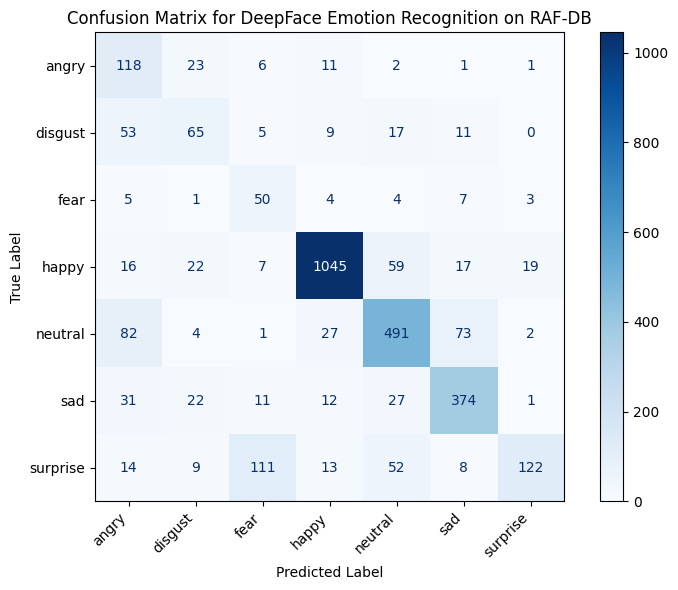

In [ ]:
show_confusion_matrix(rafdb_y_true, rafdb_y_pred, emotiefflib_emotion_order, 'RAF-DB')

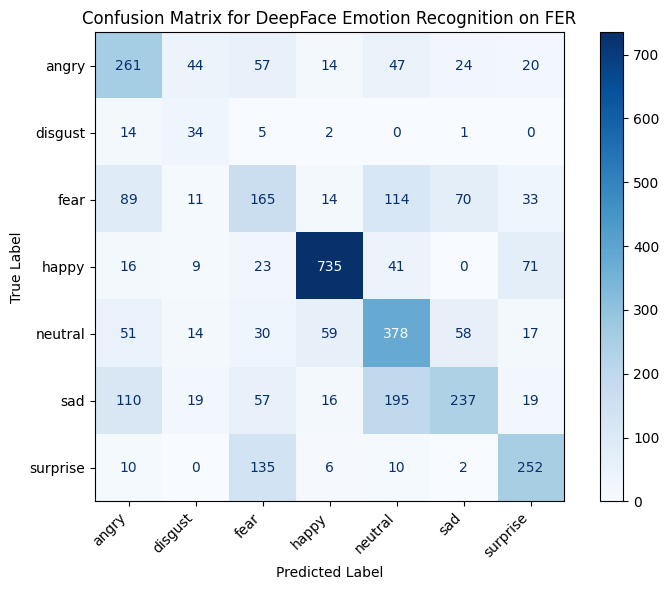

In [ ]:
show_confusion_matrix(fer_y_true, fer_y_pred, emotiefflib_emotion_order, 'FER')

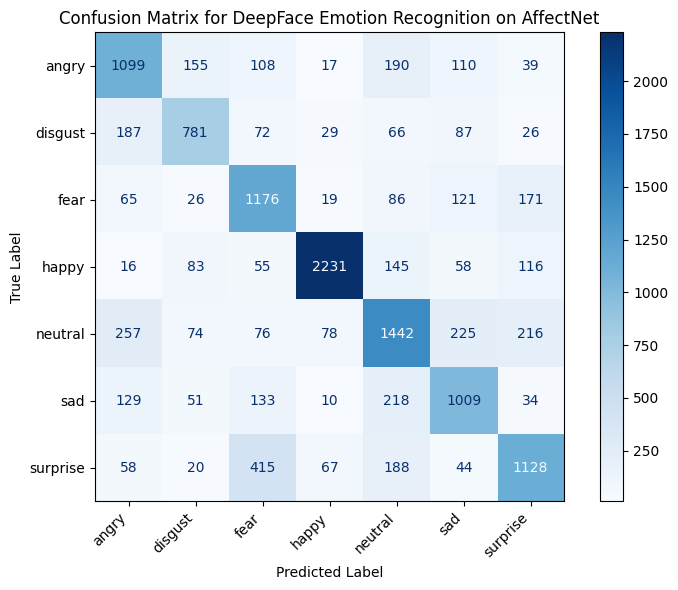

In [ ]:
show_confusion_matrix(affectnet_y_true, affectnet_y_pred, emotiefflib_emotion_order, 'AffectNet')

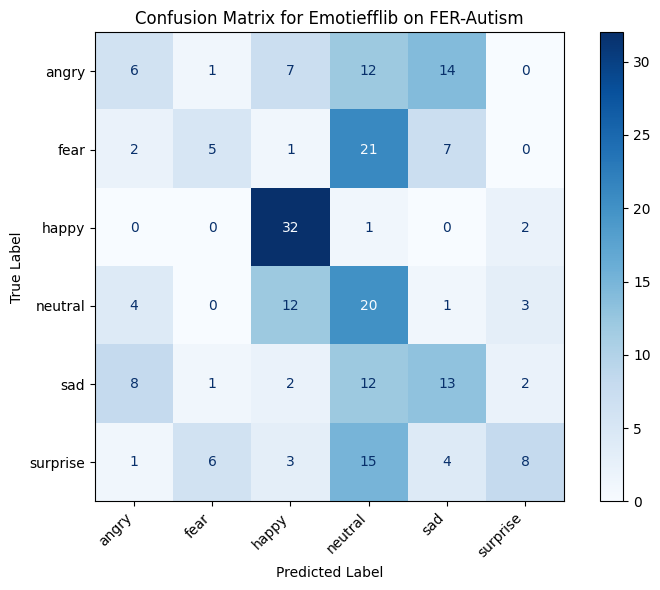

In [21]:
show_confusion_matrix(aer_y_true, aer_y_pred, emotiefflib_aer_emotion_order, 'FER-Autism')

# Create Reliability Diagram for the datasets

In [22]:
def plot_reliability_diagram(y_true, y_prob, n_bins=15, dataset=""):
    """
    Plots a multiclass reliability diagram.

    Args:
        y_true: Array of true class indices (0..N).
        y_prob: Array of predicted probabilities (N_samples, N_classes).
        n_bins: Number of bins for the calibration curve.
    """
    # 1. Get the Confidence (max prob) and Prediction for each sample
    confidences = np.max(y_prob, axis=1)
    predictions = np.argmax(y_prob, axis=1)

    # 2. Determine if prediction was correct
    accuracies = (predictions == y_true)

    # 3. Create Bins
    bin_boundaries = np.linspace(0, 1, n_bins + 1)

    bin_accuracies = []
    bin_confidences = []
    bin_counts = []

    for i in range(n_bins):
        # Define bin range
        lower, upper = bin_boundaries[i], bin_boundaries[i+1]

        # Find samples in this bin
        in_bin = (confidences > lower) & (confidences <= upper)
        count = np.sum(in_bin)
        bin_counts.append(count)

        if count > 0:
            # Calculate average accuracy and confidence for this bin
            bin_accuracies.append(np.mean(accuracies[in_bin]))
            bin_confidences.append(np.mean(confidences[in_bin]))
        else:
            bin_accuracies.append(0)
            bin_confidences.append((lower + upper) / 2)

    # --- PLOTTING ---
    plt.figure(figsize=(10, 10))

    # Subplot 1: The Reliability Curve
    ax1 = plt.subplot2grid((3, 1), (0, 0), rowspan=2)

    # Perfect calibration line (Diagonal)
    ax1.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated")

    # The Model's curve
    ax1.plot(bin_confidences, bin_accuracies, "s-", label="Model Calibration")

    # Fill areas to highlight over/under confidence
    ax1.fill_between(bin_confidences, bin_confidences, bin_accuracies,
                     where=np.array(bin_accuracies) < np.array(bin_confidences),
                     color='red', alpha=0.2, label="Overconfidence Gap")

    ax1.set_ylabel("Observed Accuracy")
    ax1.set_ylim([0, 1])
    ax1.set_xlim([0, 1])
    ax1.set_title(f"Reliability Diagram (Emotiefflib on {dataset})")
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

    # Subplot 2: Confidence Histogram (How many samples in each bin?)
    ax2 = plt.subplot2grid((3, 1), (2, 0))
    ax2.hist(confidences, bins=bin_boundaries, alpha=0.7, color='gray', edgecolor='black')
    ax2.set_xlabel("Predicted Confidence")
    ax2.set_ylabel("Count")
    ax2.set_xlim([0, 1])
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
# plot_reliability_diagram(y_true, y_pred_proba, n_bins=15, )

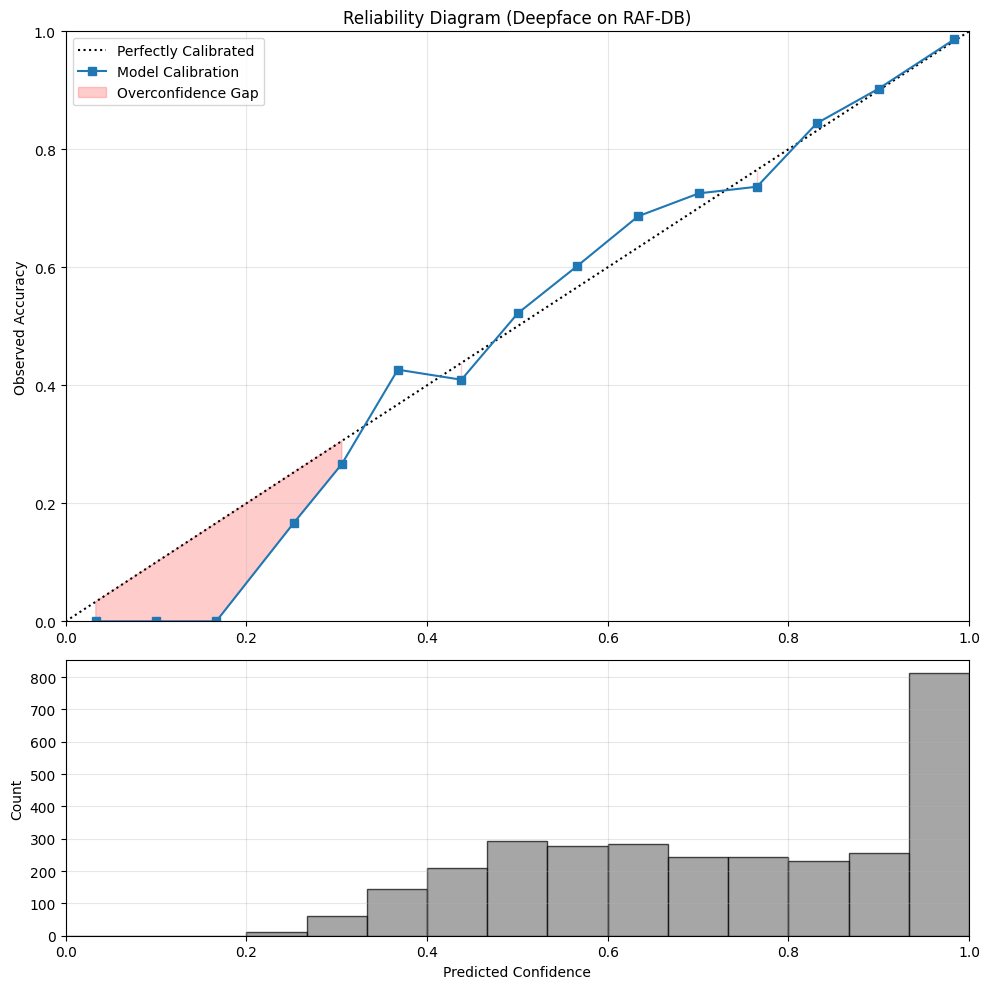

In [ ]:
plot_reliability_diagram(rafdb_y_true, rafdb_y_pred_proba, dataset='RAF-DB')

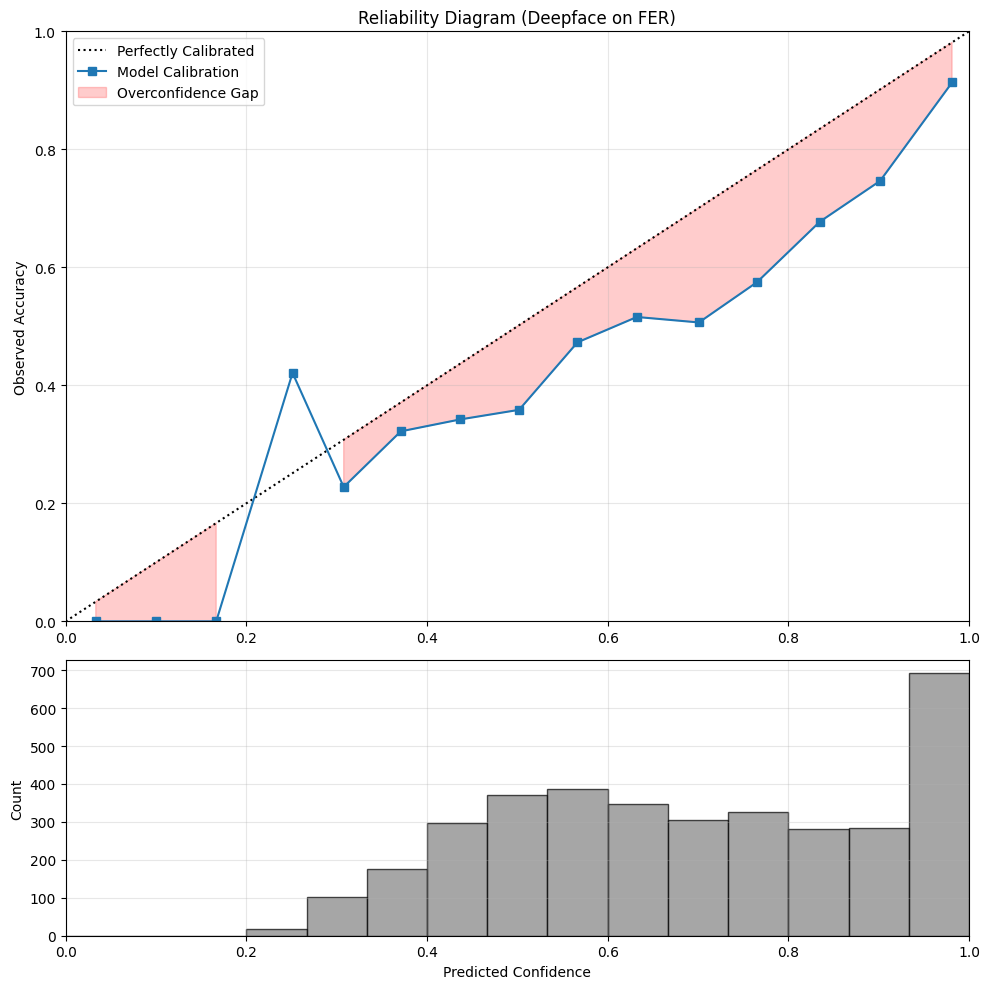

In [ ]:
plot_reliability_diagram(fer_y_true, fer_y_pred_proba, dataset='FER')

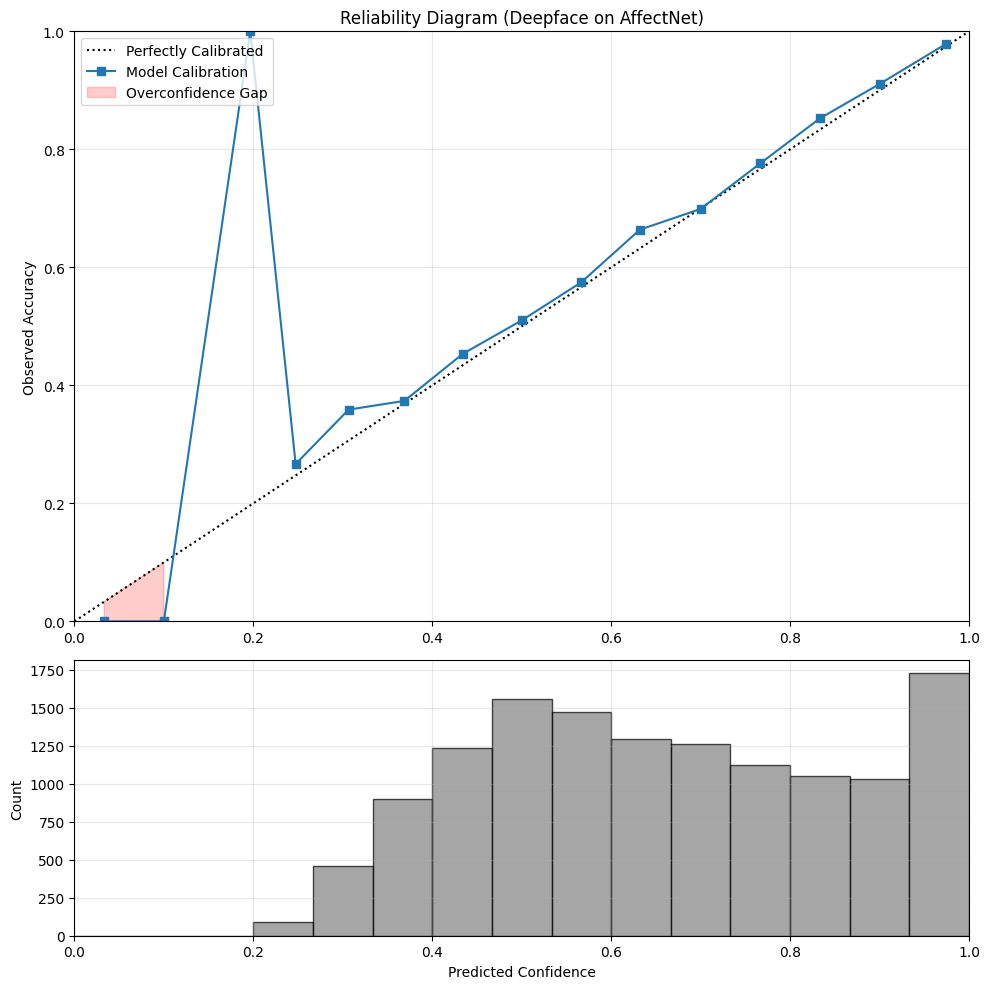

In [ ]:
plot_reliability_diagram(affectnet_y_true, affectnet_y_pred_proba, dataset='AffectNet')

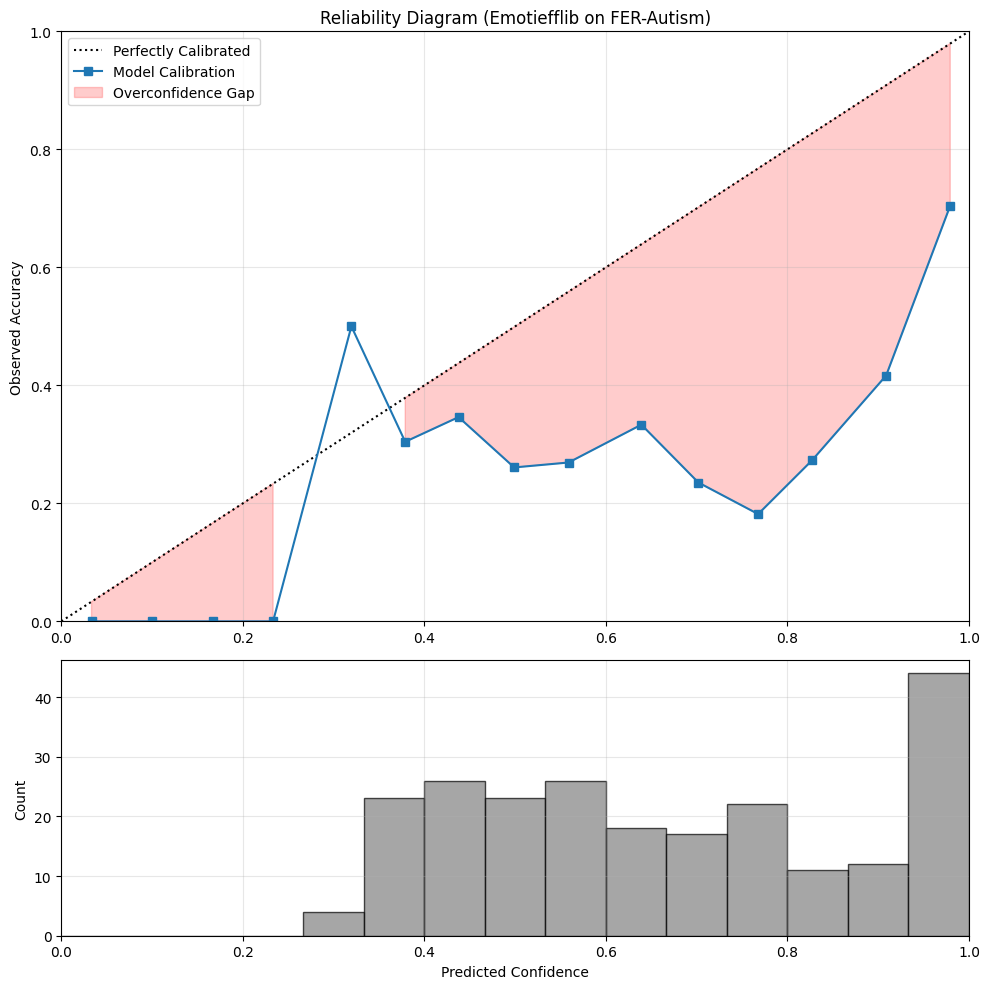

In [23]:
plot_reliability_diagram(aer_y_true, aer_y_pred_proba, dataset='FER-Autism')